In [ ]:

!pip install -U pip
!pip install -U setuptools wheel
!pip install -U "mxnet<2.0.0"
!pip install autogluon --no-cache-dir
!pip install -U pip
!pip install -U setuptools wheel
!pip install -U "mxnet<2.0.0"
!pip install autogluon --no-cache-dir

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 363.4 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mxnet 1.9.1 requires numpy<2.0.0,>1.16.0, but you have numpy 2.0.2 which is incompatible.


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 328.8 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mxnet 1.9.1 requires numpy<2.0.0,>1.16.0, but you have numpy 2.0.2 which is incompatible.


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, types as T, Window
from autogluon.tabular import TabularPredictor
from autogluon.tabular.models.knn.knn_model import KNNModel

import re

In [ ]:
CSV_PATH = "/content/Impact_of_Remote_Work_on_Mental_Health.csv"

In [ ]:
TARGET = "Satisfaction_with_Remote_Work"

In [ ]:
DROP_COLS =["Employee_ID"]
TRAIN_FRAC = 0.9
SEED = 42
PRES = "best_quality"
EVAL_METRIC = "accuracy"

In [ ]:
spark = SparkSession.builder.appName("RemoteWork_AG_Clean").getOrCreate()
df0 = spark.read.csv(CSV_PATH, header=True, inferSchema=True)

In [ ]:
df = df0.drop(*[c for c in DROP_COLS if c in df0.columns])

In [ ]:
def sanitize_columns(df):
    mapping = {}
    out = df
    for c in df.columns:
        safe = re.sub(r'[^0-9A-Za-z_]', '_', c).strip('_')
        if re.match(r'^[0-9]', safe):
            safe = f"c_{safe}"
        if safe != c:
            mapping[c] = safe
    for old, new in mapping.items():
        out = out.withColumnRenamed(old, new)
    return out, mapping

df, colmap = sanitize_columns(df)
TARGET = colmap.get(TARGET, TARGET)

if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns: {df.columns}")


In [ ]:
scalar_types = (T.StringType, T.BooleanType, T.ByteType, T.ShortType, T.IntegerType, T.LongType,
                T.FloatType, T.DoubleType, T.DecimalType, T.DateType, T.TimestampType)
keep_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, scalar_types)]
if TARGET not in keep_cols:
    keep_cols.append(TARGET)
df = df.select(*keep_cols)

df = df.filter(F.col(TARGET).isNotNull())

In [ ]:

from pyspark.sql import functions as F, types as T

def impute_median_mode(sdf, target_col):
    schema = sdf.schema

    num_types = (T.ByteType, T.ShortType, T.IntegerType, T.LongType,
                 T.FloatType, T.DoubleType, T.DecimalType)
    cat_types = (T.StringType, T.BooleanType, T.DateType, T.TimestampType)


    cols_except_target = [f.name for f in schema.fields if f.name != target_col]

    num_cols = [f.name for f in schema.fields
                if isinstance(f.dataType, num_types) and f.name in cols_except_target]
    cat_cols = [f.name for f in schema.fields
                if isinstance(f.dataType, cat_types) and f.name in cols_except_target]


    median_exprs = [
        F.expr(f"percentile_approx({F.col(c)._jc.toString()}, 0.5, 1000000)").alias(c)
        for c in num_cols
    ] if num_cols else []
    medians = {}
    if median_exprs:
        med_row = sdf.select(*median_exprs).first()
        for c in num_cols:
            val = med_row[c]
            if val is not None and not (isinstance(val, float) and (val != val)):
                medians[c] = val

    sdf_filled = sdf.fillna(medians) if medians else sdf


    for c in cat_cols:
        mode_val = (
            sdf_filled
            .where(F.col(c).isNotNull())
            .groupBy(c).count()
            .orderBy(F.desc("count"), F.asc(c))
            .limit(1)
            .collect()
        )
        if mode_val:
            fill_value = mode_val[0][0]
            sdf_filled = sdf_filled.fillna({c: fill_value})
        else:

            dt = dict(schema)[c].dataType
            if isinstance(dt, T.StringType):
                sdf_filled = sdf_filled.fillna({c: "Unknown"})
            elif isinstance(dt, T.BooleanType):
                sdf_filled = sdf_filled.fillna({c: False})
            elif isinstance(dt, (T.DateType, T.TimestampType)):

                pass

    return sdf_filled


df = impute_median_mode(df, TARGET)


df = df.filter(F.col(TARGET).isNotNull())

df_strat = df.withColumn("__u__", F.rand(SEED))
train_sdf = df_strat.where(F.col("__u__") <= TRAIN_FRAC).drop("__u__")
test_sdf  = df_strat.where(F.col("__u__") >  TRAIN_FRAC).drop("__u__")


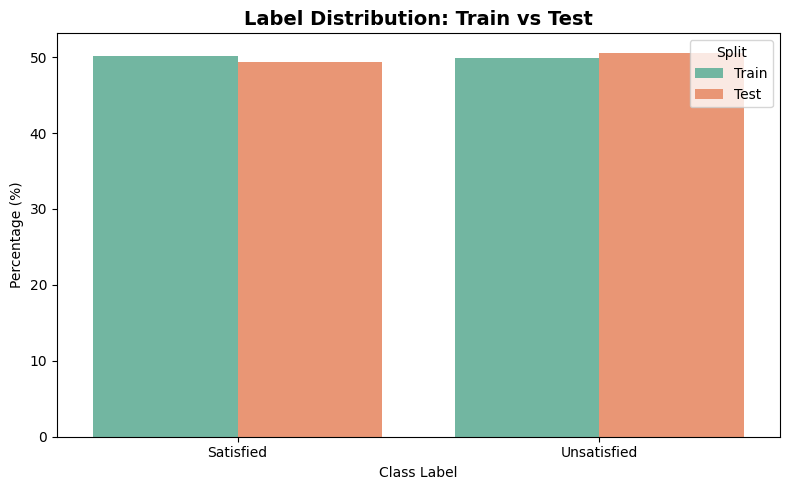

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_label_dist(sdf, lbl):

    pdf = (
        sdf.withColumn("__lbl__", F.col(lbl).cast("string"))
           .groupBy("__lbl__").count()
           .orderBy(F.desc("count"))
           .toPandas()
    )
    pdf["percent"] = pdf["count"] / pdf["count"].sum() * 100
    return pdf.rename(columns={"__lbl__": "label"})

train_dist = get_label_dist(train_sdf, TARGET)
train_dist["split"] = "Train"

test_dist = get_label_dist(test_sdf, TARGET)
test_dist["split"] = "Test"

dist_df = pd.concat([train_dist, test_dist], ignore_index=True)


plt.figure(figsize=(8,5))
sns.barplot(
    data=dist_df,
    x="label", y="percent", hue="split",
    palette="Set2"
)
plt.title("Label Distribution: Train vs Test", fontsize=14, fontweight="bold")
plt.xlabel("Class Label")
plt.ylabel("Percentage (%)")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

In [ ]:
train_df = train_sdf.toPandas()
test_df  = test_sdf.toPandas()

train_df = train_df[train_df[TARGET].notna()].copy()
test_df  = test_df[test_df[TARGET].notna()].copy()
train_df[TARGET] = train_df[TARGET].astype("category")
test_df[TARGET]  = test_df[TARGET].astype("category")

print("\n=== Shapes (Pandas) ===")
print("Train:", train_df.shape, " Test:", test_df.shape)


=== Shapes (Pandas) ===
Train: (4508, 19)  Test: (492, 19)


In [ ]:

from imblearn.over_sampling import SMOTENC
import numpy as np
import pandas as pd

SEED = 42


y = train_df[TARGET].astype(str)
X = train_df.drop(columns=[TARGET]).copy()


cat_cols = [c for c in X.columns if str(X[c].dtype) in ("category", "object")]
num_cols = [c for c in X.columns if c not in cat_cols]


for c in cat_cols:
    if str(X[c].dtype) != "category":
        X[c] = X[c].astype("category")


cat_code_maps = {}
for c in cat_cols:
    cat = X[c].cat.categories
    cat_code_maps[c] = cat
    X[c] = X[c].cat.codes


X_order = X.columns.tolist()
cat_idx = [X_order.index(c) for c in cat_cols]


sm = SMOTENC(categorical_features=cat_idx, random_state=SEED, sampling_strategy="auto")
X_res_np, y_res_np = sm.fit_resample(X.values, y.values)


X_res = pd.DataFrame(X_res_np, columns=X_order)

for c in cat_cols:
    codes = X_res[c].round().astype(int)

    codes = codes.clip(lower=0, upper=len(cat_code_maps[c]) - 1)
    X_res[c] = pd.Categorical.from_codes(codes, categories=cat_code_maps[c])


y_res = pd.Series(y_res_np, name=TARGET).astype("category")

balanced_train_df = pd.concat([X_res, y_res], axis=1)

print("Original train shape:", train_df.shape, "Balanced train shape:", balanced_train_df.shape)
print(balanced_train_df[TARGET].value_counts())


Original train shape: (4508, 19) Balanced train shape: (4518, 19)
Satisfaction_with_Remote_Work
Satisfied      2259
Unsatisfied    2259
Name: count, dtype: int64


In [ ]:
predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric=EVAL_METRIC
).fit(
    train_data=balanced_train_df,
    presets=PRES,
    time_limit=1800,
    num_bag_folds=5,
    num_stack_levels=1
    verbosity=2
)

No path specified. Models will be saved in: "AutogluonModels/ag-20250919_094618"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
Memory Avail:       10.32 GB / 12.67 GB (81.5%)
Disk Space Avail:   62.48 GB / 107.72 GB (58.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the opti

In [ ]:
print("\n=== AutoGluon label encoding map ===")
classes = list(predictor.class_labels)
for idx, lab in enumerate(classes):
    print(f"  {idx} -> {lab}")
label_to_idx = {lab: idx for idx, lab in enumerate(classes)}
print("Label→Index dict:", label_to_idx)



=== AutoGluon label encoding map ===
  0 -> Satisfied
  1 -> Unsatisfied
Label→Index dict: {'Satisfied': 0, 'Unsatisfied': 1}


In [ ]:
perf = predictor.evaluate(test_df, silent=False)
print("\n=== Performance on Spark-held-out test ===")
print(perf)

leader = predictor.leaderboard(test_df, silent=True)
print("\n=== Leaderboard ===")
print(leader)


Evaluation: accuracy on test data: 0.6788617886178862
Evaluations on test data:
{
    "accuracy": 0.6788617886178862,
    "balanced_accuracy": 0.6786156973573305,
    "mcc": 0.35756247662714286,
    "roc_auc": 0.6857553671476028,
    "f1": 0.6877470355731226,
    "precision": 0.6770428015564203,
    "recall": 0.6987951807228916
}



=== Performance on Spark-held-out test ===
{'accuracy': 0.6788617886178862, 'balanced_accuracy': np.float64(0.6786156973573305), 'mcc': np.float64(0.35756247662714286), 'roc_auc': np.float64(0.6857553671476028), 'f1': 0.6877470355731226, 'precision': 0.6770428015564203, 'recall': 0.6987951807228916}

=== Leaderboard ===
                          model  score_test  score_val eval_metric  \
0         ExtraTrees_r42_BAG_L1    0.682927   0.651394    accuracy   
1          CatBoost_r137_BAG_L1    0.678862   0.664011    accuracy   
2          CatBoost_r177_BAG_L1    0.678862   0.664453    accuracy   
3           CatBoost_r13_BAG_L1    0.678862   0.663568    accuracy   
4               CatBoost_BAG_L1    0.678862   0.663347    accuracy   
5           CatBoost_r50_BAG_L1    0.678862   0.666667    accuracy   
6            CatBoost_r9_BAG_L1    0.678862   0.666003    accuracy   
7       RandomForestEntr_BAG_L1    0.678862   0.651173    accuracy   
8           WeightedEnsemble_L2    0.678862   0

/tmp/ipython-input-1525320666.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


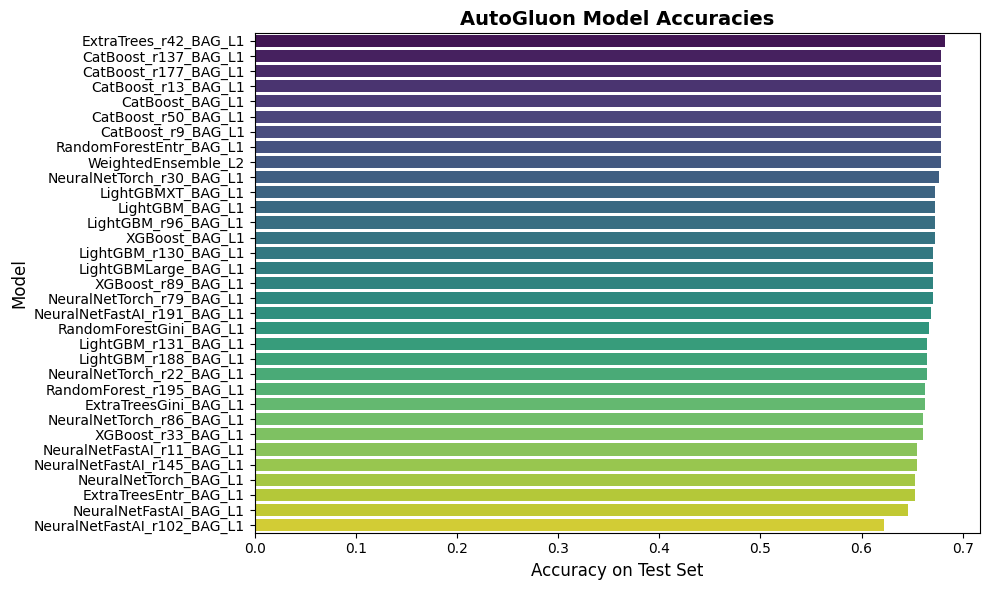

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


leader_df = leader.copy()


if "score_test" in leader_df.columns:
    score_col = "score_test"
else:

    score_col = [c for c in leader_df.columns if "score" in c][0]

plt.figure(figsize=(10,6))
sns.barplot(
    data=leader_df,
    x=score_col,
    y="model",
    palette="viridis"
)
plt.xlabel("Accuracy on Test Set", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.title("AutoGluon Model Accuracies", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

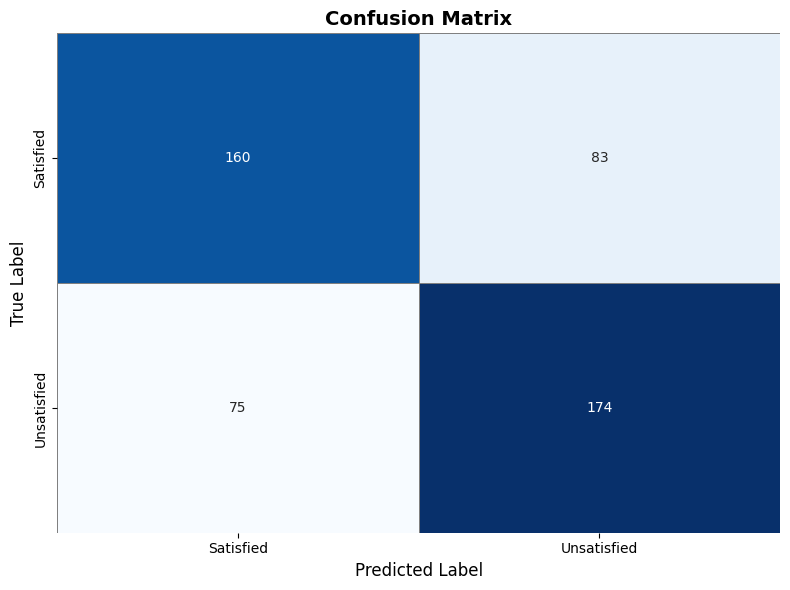

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = test_df[TARGET].astype(str)
y_pred = predictor.predict(test_df).astype(str)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=classes, yticklabels=classes,
    cbar=False, linewidths=.5, linecolor="gray"
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Computing feature importance via permutation shuffling for 18 features using 492 rows with 5 shuffle sets...
	106.45s	= Expected runtime (21.29s per shuffle set)
	35.99s	= Actual runtime (Completed 5 of 5 shuffle sets)
/tmp/ipython-input-1650685901.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


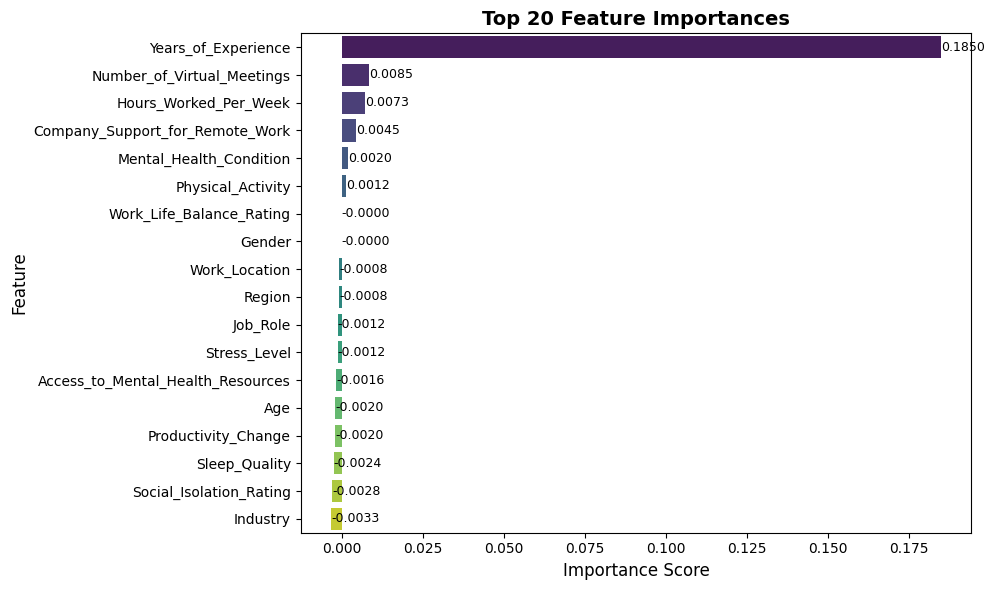

In [ ]:
topn = 20
imp = predictor.feature_importance(test_df)
imp_reset = imp.reset_index().head(topn).rename(columns={"index": "Feature"})

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=imp_reset,
    x="importance",
    y="Feature",
    palette="viridis"
)


for i, (val, feat) in enumerate(zip(imp_reset["importance"], imp_reset["Feature"])):
    ax.text(
        val, i, f"{val:.4f}",
        va="center", ha="left", fontsize=9, color="black"
    )

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title(f"Top {topn} Feature Importances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

y_train_raw = balanced_train_df[TARGET].astype(str).copy()
X_train_raw = balanced_train_df.drop(columns=[TARGET]).copy()

y_test_raw  = test_df[TARGET].astype(str).copy()
X_test_raw  = test_df.drop(columns=[TARGET]).copy()


cat_cols = [c for c in X_train_raw.columns if str(X_train_raw[c].dtype) in ("object","category","bool")]
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]


for c in cat_cols:
    if str(X_train_raw[c].dtype) != "category":
        X_train_raw[c] = X_train_raw[c].astype("category")
    if c in X_test_raw.columns and str(X_test_raw[c].dtype) != "category":
        X_test_raw[c] = X_test_raw[c].astype("category")


def one_hot_align(train_df, test_df, categorical_cols):
    train = train_df.copy()
    test  = test_df.copy()


    for c in categorical_cols:
        cats_train = pd.Index(train[c].cat.categories)
        cats_test  = pd.Index(test[c].cat.categories)
        union_cats = pd.CategoricalDtype(categories=pd.Index(sorted(set(cats_train).union(cats_test))))
        train[c] = train[c].astype(union_cats)
        test[c]  = test[c].astype(union_cats)


    train["__split__"] = "train"
    test["__split__"]  = "test"
    combo = pd.concat([train, test], ignore_index=True)


    combo_ohe = pd.get_dummies(combo, columns=categorical_cols, dummy_na=False)

    train_ohe = combo_ohe[combo_ohe["__split__"] == "train"].drop(columns="__split__")
    test_ohe  = combo_ohe[combo_ohe["__split__"]  == "test"].drop(columns="__split__")
    return train_ohe, test_ohe

X_train_enc, X_test_enc = one_hot_align(X_train_raw, X_test_raw, cat_cols)


le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)
class_names = list(le.classes_)
print("Class names (label encoder order):", class_names)


xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1
)
xgb.fit(X_train_enc, y_train)


y_pred = xgb.predict(X_test_enc)
print("\n[XGB] Test accuracy:", accuracy_score(y_test, y_pred))
print("[XGB] Classification report:\n", classification_report(y_test, y_pred, target_names=class_names))








Class names (label encoder order): ['Satisfied', 'Unsatisfied']

[XGB] Test accuracy: 0.6199186991869918
[XGB] Classification report:
               precision    recall  f1-score   support

   Satisfied       0.61      0.63      0.62       243
 Unsatisfied       0.63      0.61      0.62       249

    accuracy                           0.62       492
   macro avg       0.62      0.62      0.62       492
weighted avg       0.62      0.62      0.62       492



In [ ]:

explainer = shap.TreeExplainer(xgb)
sv = explainer.shap_values(X_test_enc)

def to_classwise_shap_binary(sv_any, class_names):
    """Return dict {class_label -> shap_matrix} with shape (n_samples, n_features)."""
    if isinstance(sv_any, list):
        if len(sv_any) == 2:
            return {class_names[0]: np.array(sv_any[0]), class_names[1]: np.array(sv_any[1])}
        raise RuntimeError("Unexpected SHAP list length (expected 2 for binary).")
    if isinstance(sv_any, np.ndarray):
        if sv_any.ndim == 2:
            pos = sv_any
            neg = -pos
            return {class_names[0]: neg, class_names[1]: pos}
        if sv_any.ndim == 3:
            return {class_names[i]: sv_any[:, i, :] for i in range(len(class_names))}
    raise RuntimeError("Unexpected SHAP shape.")

sv_by_class = to_classwise_shap_binary(sv, class_names)
feature_names = np.array(X_train_enc.columns)



=== Top-3 features by mean |SHAP| for each class (XGBoost, no AutoGluon) ===
Class: Satisfied
  Years_of_Experience: 0.931345
  Hours_Worked_Per_Week: 0.225786
  Age: 0.205617
Class: Unsatisfied
  Years_of_Experience: 0.931345
  Hours_Worked_Per_Week: 0.225786
  Age: 0.205617


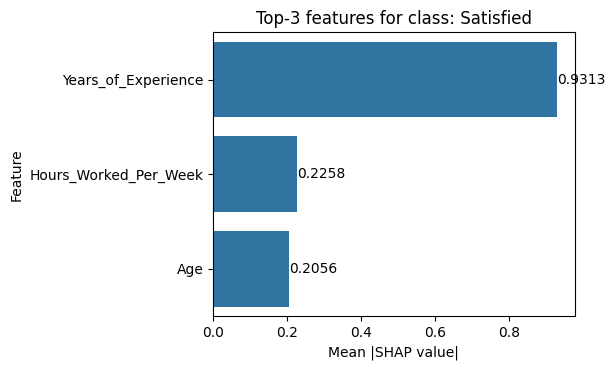

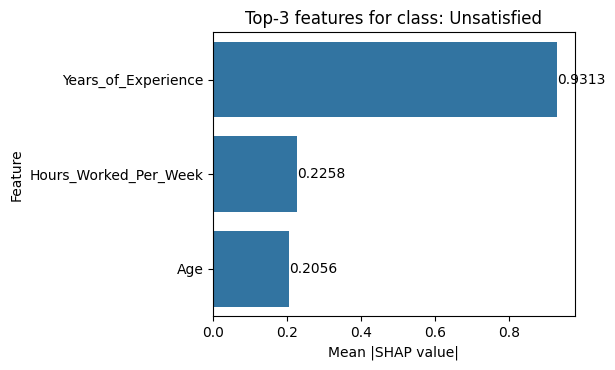

In [ ]:


def topk_for_class(sv_mat, names, k=3):
    mean_abs = np.abs(sv_mat).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:k]
    return names[idx], mean_abs[idx]

top3 = {}
for lab in class_names:
    f, s = topk_for_class(sv_by_class[lab], feature_names, k=3)
    top3[lab] = (f, s)

print("\n=== Top-3 features by mean |SHAP| for each class (XGBoost, no AutoGluon) ===")
for lab in class_names:
    f, s = top3[lab]
    print(f"Class: {lab}")
    for name, score in zip(f, s):
        print(f"  {name}: {score:.6f}")

def plot_top3_bar(label_name):
    f, s = top3[label_name]
    order = np.argsort(s)[::-1]
    f = f[order]
    s = s[order]
    plt.figure(figsize=(6.2, 3.8))
    sns.barplot(x=s, y=f)
    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Feature")
    plt.title(f"Top-3 features for class: {label_name}")
    ax = plt.gca()
    for i, v in enumerate(s):
        ax.text(v, i, f"{v:.4f}", va="center", ha="left")
    plt.tight_layout()
    plt.show()


for lab in class_names:
    plot_top3_bar(lab)

/tmp/ipython-input-3470734872.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_by_class[pos_label], X_test_enc, feature_names=feature_names, show=True, max_display=20)


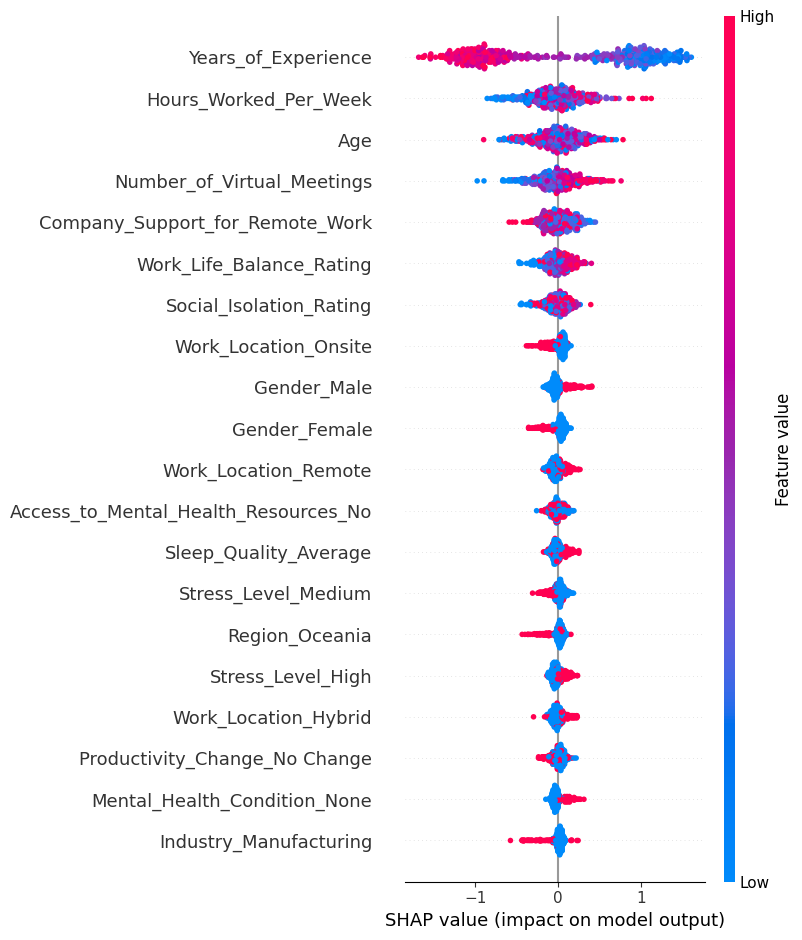

In [ ]:

pos_label = class_names[1]
try:
    shap.summary_plot(sv_by_class[pos_label], X_test_enc, feature_names=feature_names, show=True, max_display=20)
except Exception as e:
    print("[INFO] Could not render SHAP beeswarm (often due to non-numeric dtypes). Error:", e)